In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation, plot_residuals
from skforecast.metrics import calculate_coverage

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import warnings
warnings.filterwarnings('once')

In [6]:
df = (pd.read_csv("../data/raw/loadtempday_clean.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [7]:
df.head()

,Demand,Temperature,is_day
date,,,
2023-01-01 00:00:00,28291.0,11.3615,0
2023-01-01 01:00:00,28727.0,9.5615,0
2023-01-01 02:00:00,28370.0,7.9615,0
2023-01-01 03:00:00,27955.0,7.3115,0
2023-01-01 04:00:00,27668.0,6.2615,0


In [8]:
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [9]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Baseline Forecaster
- seasonal naive forecaster used to compare performance of future models
- trained and evaluated with backtesting
- predicts each hour using the value of the same hour on the previous day

In [10]:
# Create baseline: value of the same hour of the previous day
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# Train forecaster
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [11]:
# Create cross validation folds to test all models
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:VAL_END]),
        refit              = False
)

In [12]:
#Base line forecaster evaluation
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data['Demand'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 294.16it/s]


,mean_absolute_error
0,1560.271233


### Recursive Multi-step forecast
- use gradient descent for the estimator (the enginge that solves the Ax = y matrix)
- forecaster handles creating the matrix from the time series
- will use 24 lags to predict the outcome
- basic auto regressive model

In [13]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [14]:
#Back test auto-regressive model
ar_metric, ar_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 346.91it/s]


,mean_absolute_error
0,1371.449927


In [15]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [16]:
#Back test auto-regressive moving average model
arma_metric, arma_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
arma_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 161.57it/s]


,mean_absolute_error
0,1416.300394


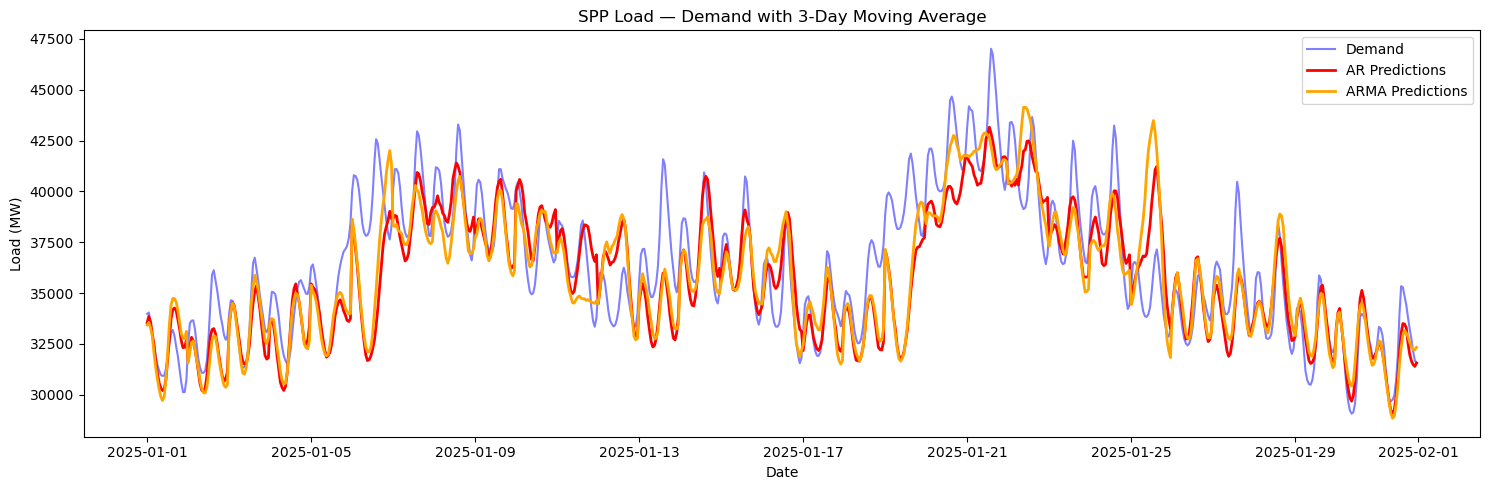

In [17]:
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)
ax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

issue with big divergence with large increases/decreases in load. the prediction and actual are almost opposites of each other. This is a major flaw as large swings in load would be of greater importance when planning based on a forecast

### Exogenous Variables
- values of the exogenous variables must be known at the time of prediction.
- we will use temperature, daylight time, and calendar features

In [18]:
from features import set_holidays, cal_features, cyclic_features

In [19]:
data = df.copy()
data = (data
            .pipe(set_holidays)
            .pipe(cal_features)
            .pipe(cyclic_features)
            .assign(Holiday=lambda d: d["Holiday"].astype(int))
            .assign(Temp_3D_Mean=lambda d: d["Temperature"].rolling("3D", center = False).mean())
            .assign(Temp_2D_Mean =lambda d: d["Temperature"].rolling("2D", center = False).mean())
            .assign(Temp_2D_Max =lambda d: d["Temperature"].rolling("2D", center = False).max())
            .assign(Temp_2D_Min =lambda d: d["Temperature"].rolling("2D", center = False).min())
            .assign(Temp_1D_Max =lambda d: d["Temperature"].rolling("1D", center = False).max())
            .assign(Temp_1D_Min =lambda d: d["Temperature"].rolling("1D", center = False).min())
           )

In [20]:
data.head()

,Demand,Temperature,is_day,Holiday,month,week,day_of_week,hour,month_sin,month_cos,...,day_sin,day_cos,hour_sin,hour_cos,Temp_3D_Mean,Temp_2D_Mean,Temp_2D_Max,Temp_2D_Min,Temp_1D_Max,Temp_1D_Min
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,28291.0,11.3615,0,0,1,52,6,0,0.5,0.866025,...,-0.781831,0.62349,0.000000,1.000000,11.361500,11.361500,11.3615,11.3615,11.3615,11.3615
2023-01-01 01:00:00,28727.0,9.5615,0,0,1,52,6,1,0.5,0.866025,...,-0.781831,0.62349,0.258819,0.965926,10.461500,10.461500,11.3615,9.5615,11.3615,9.5615
2023-01-01 02:00:00,28370.0,7.9615,0,0,1,52,6,2,0.5,0.866025,...,-0.781831,0.62349,0.500000,0.866025,9.628167,9.628167,11.3615,7.9615,11.3615,7.9615
2023-01-01 03:00:00,27955.0,7.3115,0,0,1,52,6,3,0.5,0.866025,...,-0.781831,0.62349,0.707107,0.707107,9.049000,9.049000,11.3615,7.3115,11.3615,7.3115
2023-01-01 04:00:00,27668.0,6.2615,0,0,1,52,6,4,0.5,0.866025,...,-0.781831,0.62349,0.866025,0.500000,8.491500,8.491500,11.3615,6.2615,11.3615,6.2615


In [21]:
exo_vars = list(data.columns)[1:]
exo_vars

['Temperature',
 'is_day',
 'Holiday',
 'month',
 'week',
 'day_of_week',
 'hour',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'Temp_3D_Mean',
 'Temp_2D_Mean',
 'Temp_2D_Max',
 'Temp_2D_Min',
 'Temp_1D_Max',
 'Temp_1D_Min']

In [22]:
#resplit the data
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


In [23]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
arma_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [24]:
# back test the model again with exogenous variables
metric, predictions = backtesting_forecaster(
                          forecaster = arma_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 139.88it/s]


,mean_absolute_error
0,1049.908173


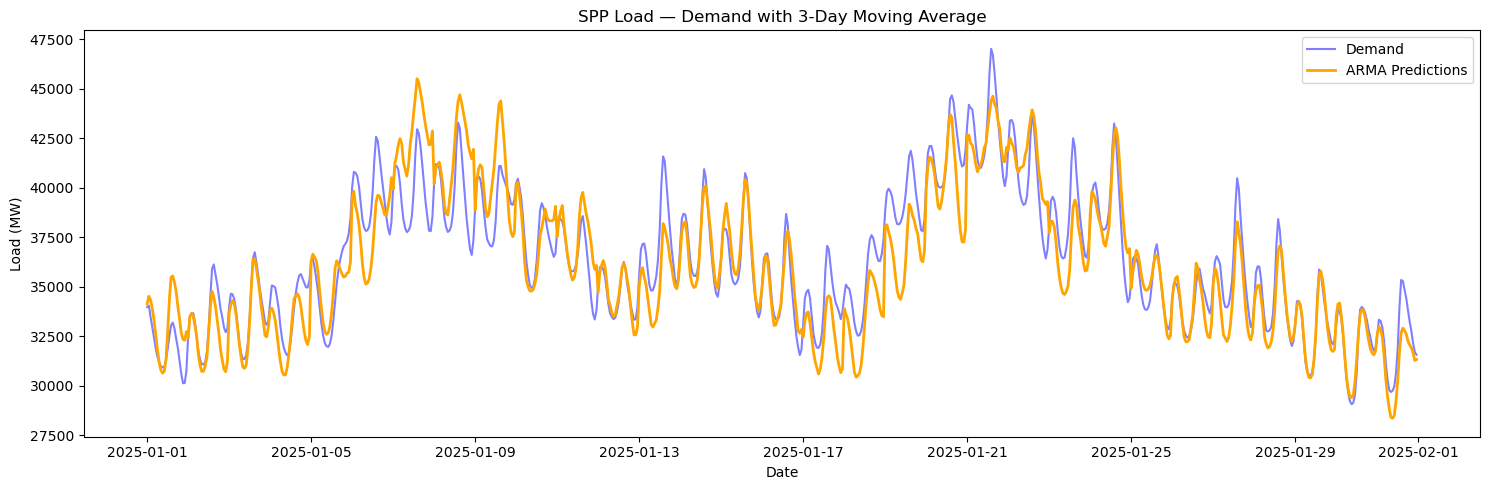

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="red", linewidth=2)
ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

visually the predictions are much loser to the actual demand, there is still a divergence around the 20th of january where the predictions move in the opposite direction of the acutal demand. this could be worth investigating more. 

In [26]:
#basic autoregressive
ar_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )

In [27]:
metric, predictions = backtesting_forecaster(
                          forecaster = ar_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 192.73it/s]


,mean_absolute_error
0,1051.133068


,fold,pred
2025-01-01 00:00:00,0,33989.335307
2025-01-01 01:00:00,0,34375.067999
2025-01-01 02:00:00,0,34166.889101
2025-01-01 03:00:00,0,33746.799743
2025-01-01 04:00:00,0,33142.218565


### Feature Importance before selection process
- we can use the feature importance feature of the forecaster to get a feel of which features should be selected
- pair this with domian knowledge should give us an inituitve idea of what features we would expect feature selection to select

In [28]:
ar_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [29]:
ar_forecaster.get_feature_importances(sort_importance=True)

,feature,importance
0,lag_1,591
37,hour_sin,226
24,Temperature,199
30,hour,155
29,day_of_week,114
38,hour_cos,111
23,lag_24,105
2,lag_3,95
21,lag_22,87
1,lag_2,78


- the exogenous variables reduce the error of the model and it makes the model with moving average out perform the basic auto regressive model. possible extensions of exogenous variables could include different window sizes of mean weather and creating polynomial features form the exogenous variables to capture inreaction
- interesting that the month feautres are some of the least important feautres
- lags [1,24,3,22,2,21,4,23,20

In [30]:
#create a model with longer lags
ar_week_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 175,
             )

In [31]:
ar_week_forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [32]:
ar_week_forecaster.get_feature_importances(sort_importance=True).head(40)

,feature,importance
0,lag_1,600
25,lag_26,126
21,lag_22,109
1,lag_2,79
26,lag_27,78
20,lag_21,78
22,lag_23,62
27,lag_28,61
24,lag_25,59
2,lag_3,53


In [33]:
lags_df = ar_week_forecaster.get_feature_importances(sort_importance=True).head(40)
lags_df["lags"] = lags_df["feature"].str.strip("lag_").astype(int)
top_lags = lags_df.lags.to_list()[:15]
top_lags.append(24)
top_lags

[1, 26, 22, 2, 27, 21, 23, 28, 25, 3, 170, 167, 20, 4, 10, 24]

### Feature Selection
- will use a simple model to find the best features and then retrain with more complex model
- will also use a smaller subset of the data to select features than the modeling training step

In [37]:
#create estimator(solver) and the forecaster (matrix formulation)
estimator = LGBMRegressor(
                n_estimators = 100,
                max_depth    = 4,
                random_state = 15926,
                verbose      = -1
            )

forecaster = ForecasterRecursive(
                 estimator       = estimator,
                 lags            = top_lags,
             )

In [38]:
# Recursive feature elimination with cross-validation
# doing cv and a subsample might have introduced noise that elimated the Holiday feature
# by domain knowledge holiday and a 24 hour lag should likely be in the model
# issue could be with feature selection setup
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
selector = RFECV(
    estimator = estimator,
    step      = 1,
    cv        = 5,
)
lags_select, window_features_select, exog_select = select_features(
    forecaster      = forecaster,
    selector        = selector,
    y               = data_train['Demand'],
    exog            = data_train[exo_vars],
    select_only     = None,
    force_inclusion = ["lag_24", "Holiday"],
    random_state    = 123,
    verbose         = True,
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 12958
Total number of records used for feature selection: 6479
Number of features available: 37
    Lags            (n=16)
    Window features (n=0)
    Exog            (n=21)
Number of features selected: 30
    Lags            (n=16) : [1, 2, 3, 4, 10, 20, 21, 22, 23, 24, 25, 26, 27, 28, 167, 170]
    Window features (n=0) : []
    Exog            (n=15) : ['Temperature', 'Holiday', 'week', 'day_of_week', 'hour', 'week_sin', 'week_cos', 'day_sin', 'hour_sin', 'hour_cos', 'Temp_3D_Mean', 'Temp_2D_Max', 'Temp_2D_Min', 'Temp_1D_Max', 'Temp_1D_Min']


In [39]:
#retrain the model and cross validate
# Create a forecaster with the selected features
forecaster = ForecasterRecursive(
                estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = lags_select
             )
# Backtesting model with exogenous variables on test data
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data['Demand'],
                            exog       = data[exog_select],
                            cv         = cv,
                            metric     = 'mean_absolute_error'
                      )                
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 212.69it/s]


,mean_absolute_error
0,1034.364163


In [57]:
forecaster.fit(y=data.loc[:VAL_END, 'Demand'], 
               exog=data.loc[:VAL_END, exog_select],
               store_in_sample_residuals=True)

print(forecaster.in_sample_residuals_)

[ 224.21636729 -410.14965613   25.50465393 ... -163.91948029  400.22657974
  -85.12563595]


In [58]:
residuals = pd.Series(forecaster.in_sample_residuals_)
print(residuals.describe())

count    10000.000000
mean         2.631756
std        265.217181
min      -4049.675298
25%       -144.017641
50%          1.189536
75%        149.583339
max       3313.779646
dtype: float64


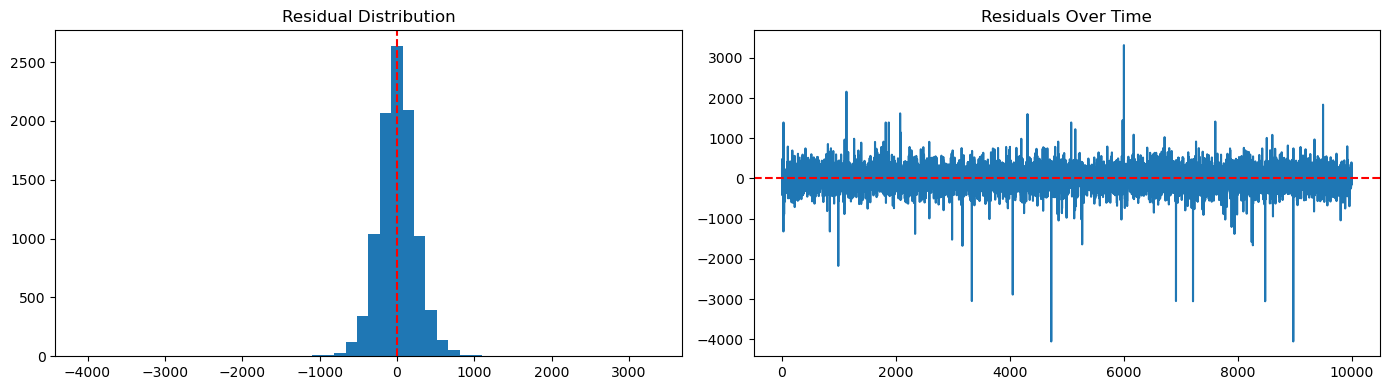

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

the error did increase when using only the selected features but it is not a huge increase. Maybe we need to add a wider variety of features to test

### Hyper Parameter Tuning

In [163]:
# Hyperparameters search
# ==============================================================================
"""
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"
"""
tuned_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = lags_select
             )

# Estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
    } 
    return search_space

# Folds training and validation
cv_search = TimeSeriesFold(
                steps              = 24,
                initial_train_size = len(data[:TRAIN_END]),
                refit              = False,
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                   forecaster   = tuned_forecaster,
                                   y            = data.loc[:VAL_END, 'Demand'],
                                   exog         = data.loc[:VAL_END, exog_select],
                                   cv           = cv_search,
                                   metric       = 'mean_absolute_error',
                                   search_space = search_space,
                                   n_trials     = 10,  # Increase for more exhaustive search
                                   return_best  = True
                               )
tuned_forecaster

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:82: FutureWarning: `consider_endpoints` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
Best trial: 3. Best value: 822.202: 100%|██████████████████████████| 10/10 [00:17<00:00,  1.75s/it]


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [  1   2   3   4  10  20  21  22  23  24  25  26  27  28 167 170] 
Window features: None 
Window size: 170 
Series name: Demand 
Exogenous included: True 
Exogenous names: 
    Temperature, week, day_of_week, hour, week_sin, hour_sin, hour_cos,
    Temp_3D_Mean, Temp_2D_Max, Temp_2D_Min, Temp_1D_Min 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.09597136051227133,
    'max_depth': 4, 'min_child_samples': 20, 'min_child_weight': 0.001,
    'min_split_gain': 0.0, 'n_estimators': 800, 'n_jobs': None, 'num_leaves':
    31, 'objective': None, 'random_state': 15926, 'reg_alpha':
    0.5315513738418384, 'reg_lambda': 0.5318275870968661, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-25 11:42:02 
Last fit date: 2026-06-25 11:42:21 
Skforecast version: 0.22.0 
Python version: 3.11.13 
Forecaster id: None

In [164]:
# Backtest final model on test data
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster = tuned_forecaster,
                          y          = data['Demand'],
                          exog       = data[exog_select],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 180.00it/s]


,mean_absolute_error
0,1063.146827


,fold,pred
2025-01-01 00:00:00,0,33989.824806
2025-01-01 01:00:00,0,34642.194480
2025-01-01 02:00:00,0,34567.177639
2025-01-01 03:00:00,0,34568.160098
2025-01-01 04:00:00,0,34135.667293


-well the error went up so idk what to do about that